## FEATURE IMPORTANCES

### Import des modules

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import pointbiserialr, chi2_contingency
import mlflow
import mlflow.sklearn 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, roc_curve, precision_recall_curve, classification_report, confusion_matrix)
import shap
from sklearn.metrics import make_scorer
from sklearn.inspection import permutation_importance



In [3]:
# Chargement des données
X_test_prep = pd.read_csv("data/X_test_prep_outliers_missing_flag.csv")
y_test_prep = pd.read_csv("data/y_test_prep_outliers_missing_flag.csv")

In [4]:
#Chargement du modèle + pipeline + X_test + y_test
best_model = joblib.load("best_model.joblib")

# Chargement du run id
with open("best_run_id.txt", "r") as f:
    best_run_id = f.read().strip()

# Chargement du modèle mlflow
pipe = mlflow.sklearn.load_model(f"runs:/{best_run_id}/model")

preprocessor = pipe.named_steps["preprocess"]
model = pipe.named_steps["model"]



In [ ]:
# Application des transformation sur les données de test
X_test_transformed = preprocessor.transform(X_test_prep)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Forcer en float
X_test_transformed = X_test_transformed.astype(float)

# Récupérer les noms de features après preprocessing
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    # fallback si get_feature_names_out n'existe pas
    feature_names = [f"feature_{i}" for i in range(X_test_transformed.shape[1])]

#### Importance globale - Toutes classes

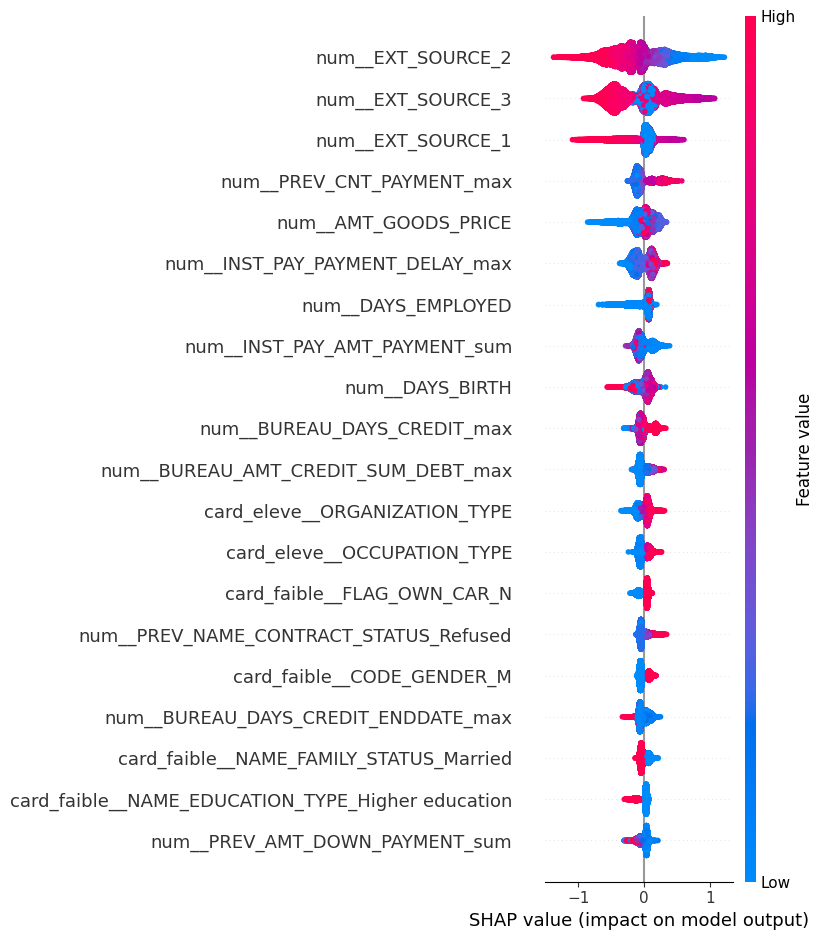

In [ ]:
# Construire l’explainer SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

# SHAP global - toutes classes
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=True)

#### Importance globale - Mauvais payeurs

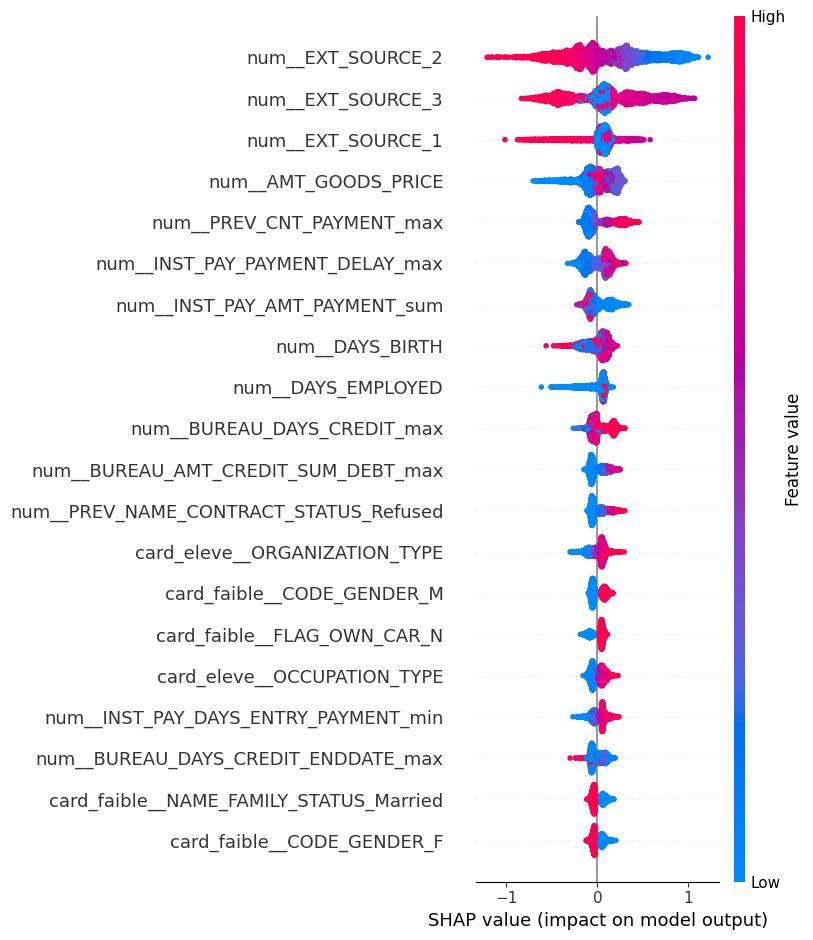

In [7]:
# SHAP global/local pour la classe "mauvais payeur"
bad_idx = y_test_prep[y_test_prep.squeeze() == 1].index

shap.summary_plot(shap_values[bad_idx], X_test_transformed[bad_idx], feature_names=feature_names, show=True)


#### Importance Locale - Mauvais payeur

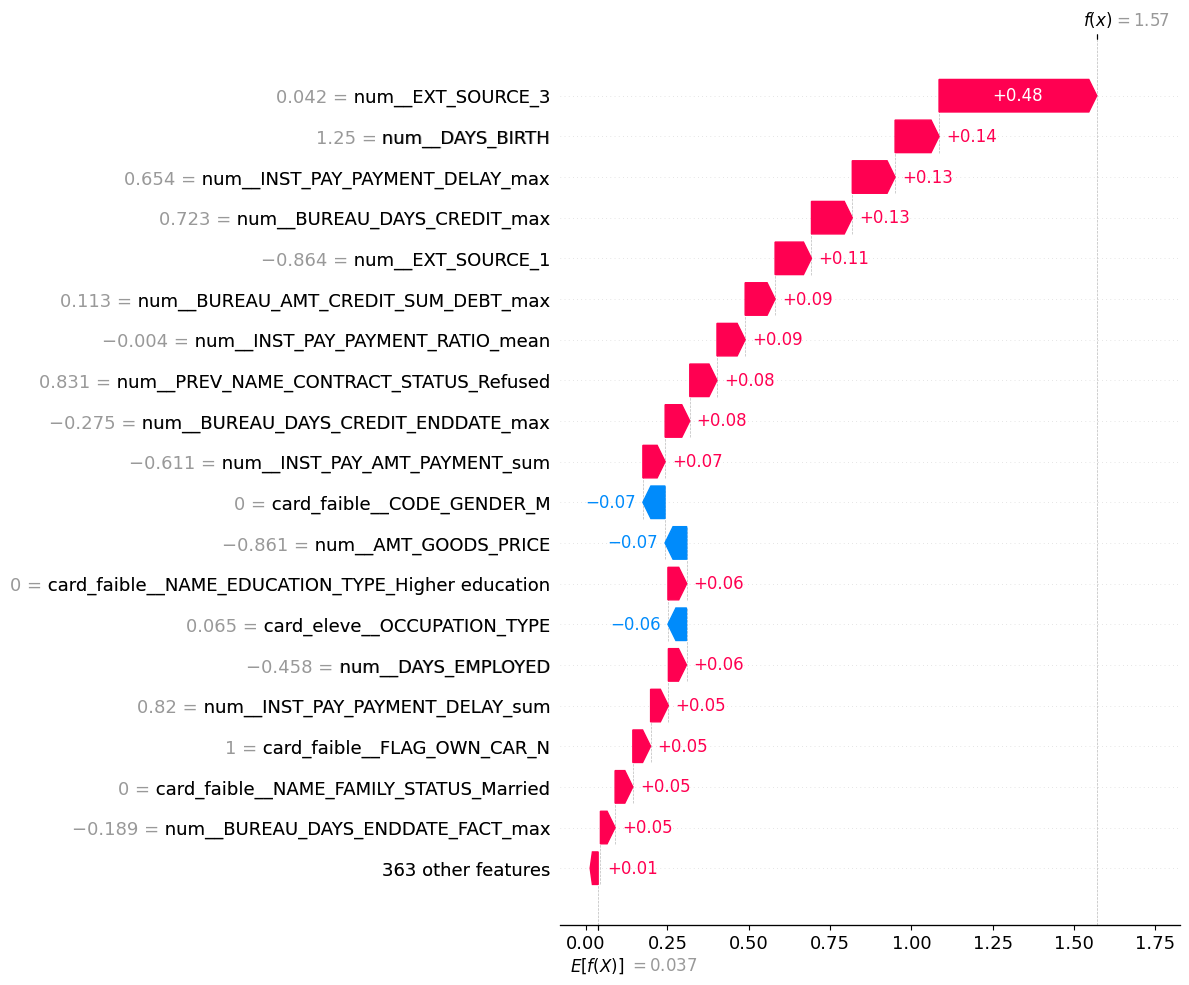

In [8]:
# SHAP localpour un mauvais payeur expliquant pourquoi il est classé comme un mauvais payeur

# Filtrer un mauvais payeur
i = bad_idx[0]

shap_exp = shap.Explanation(values=shap_values[i], base_values=explainer.expected_value, data=X_test_transformed[i], feature_names=feature_names)

shap.plots.waterfall(shap_exp, max_display=20)


#### Importance Locale - Bon payeur

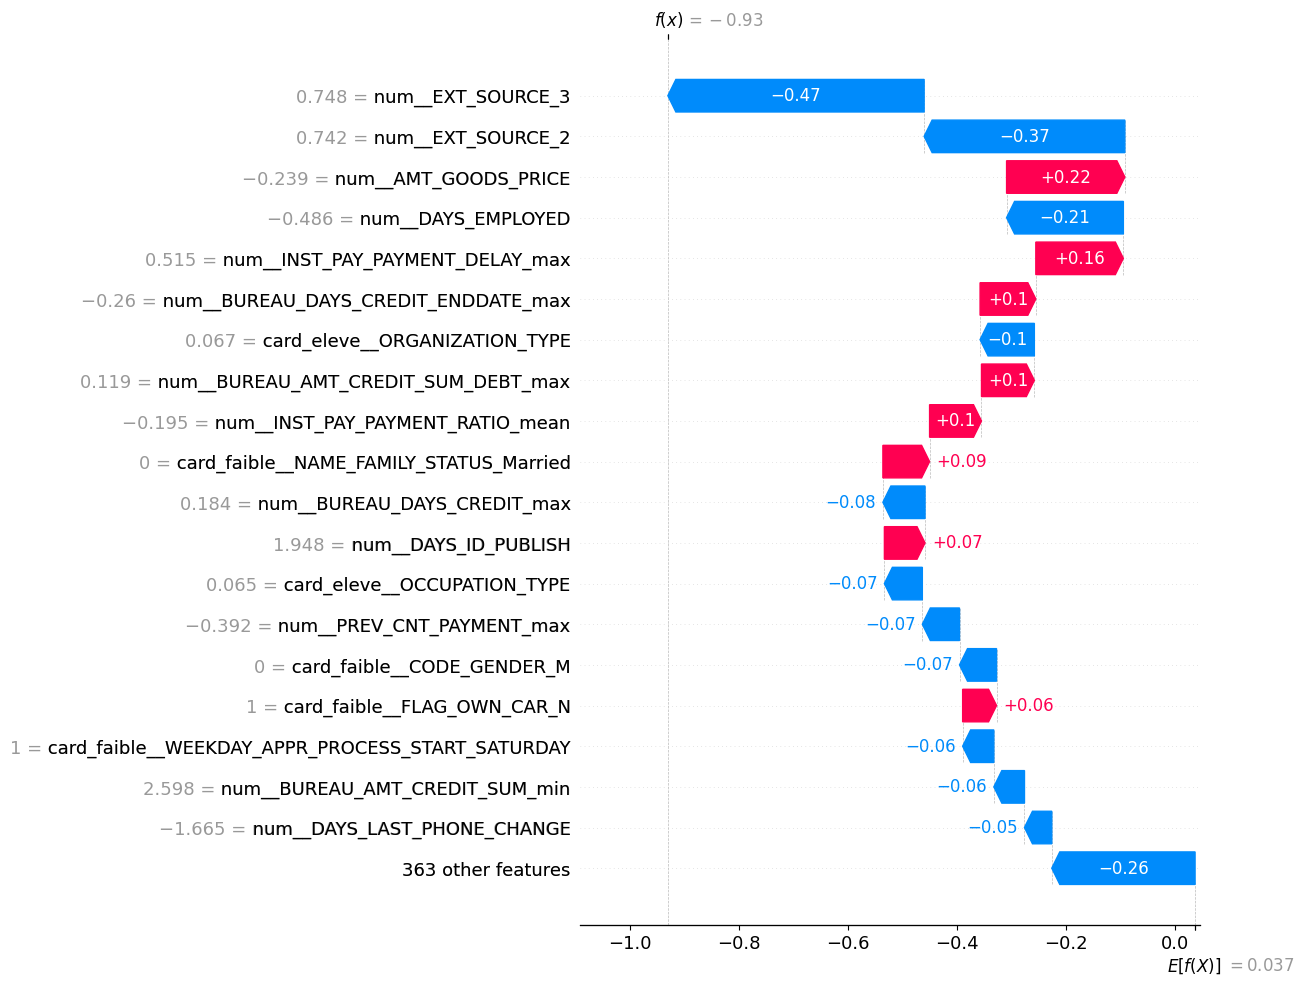

In [9]:
# SHAP localpour un bon payeur expliquant pourquoi il est classé comme un bon payeur
goog_idx = y_test_prep[y_test_prep.squeeze() == 0].index

# Filtrer un bon payeur
b = goog_idx[3]

shap_exp = shap.Explanation(values=shap_values[b], base_values=explainer.expected_value, data=X_test_transformed[b], feature_names=feature_names)

shap.plots.waterfall(shap_exp, max_display=20)